# **Практическая работа №7. Применение методов машинного обучения для решения задач классификации текстов. Метод Наивного Байеса. Метод опорных векторов**

## Задание 0. Найдите в глобальной сети или соберите свой датасет для классификации текстов (Пример: новости -> рубрики, комментарии в соц. сетях -> характер, )

* Количество классов в датасете должно превышать 2
* Язык текста в датасете: русский

- ### Пример датасетов: [Russian Texts](https://www.kaggle.com/datasets?search=text+classification+russian)

### Загрузите датасет

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Небольшой собственный датасет, в нем три класса: спорт, технологии и культура

texts = [
    'Футболисты команды провели тренировку перед матчем чемпионата.',
    'Команда одержала победу в финале турнира по футболу.',
    'Баскетболист набрал двадцать очков за игру.',
    'Теннисист вышел в полуфинал соревнования.',
    'Хоккейный клуб подписал нового нападающего.',
    'Спортсмен установил рекорд на дистанции сто метров.',
    'Тренер рассказал о подготовке команды к сезону.',
    'Сборная России сыграла товарищеский матч.',
    'Футбольный матч завершился со счетом два один.',
    'Вратарь сделал несколько важных сейвов.',
    'Легкоатлет выиграл золотую медаль на чемпионате.',
    'Баскетбольная команда начала подготовку к плей-офф.',
    'Хоккеисты провели утреннюю тренировку на льду.',
    'Теннисный турнир пройдет в Москве на следующей неделе.',
    'Спортсмены готовятся к олимпийским соревнованиям.',
    'Футбольный клуб объявил о переходе полузащитника.',
    'Команда заняла первое место в турнирной таблице.',
    'Главный тренер назвал состав на предстоящую игру.',
    'Боксер победил соперника в четвертом раунде.',
    'Пловец завоевал медаль на международных соревнованиях.',
    'Компания представила новый смартфон с мощным процессором.',
    'Разработчики выпустили обновление операционной системы.',
    'Искусственный интеллект помогает анализировать большие данные.',
    'Новый ноутбук получил более быстрый твердотельный накопитель.',
    'Программисты создали приложение для обработки фотографий.',
    'Процессор нового поколения стал производительнее предыдущей модели.',
    'Видеокарта получила поддержку новой технологии трассировки лучей.',
    'Ученые разработали новый алгоритм машинного обучения.',
    'Сервис добавил функцию автоматического перевода текста.',
    'Компания показала прототип робота для домашнего использования.',
    'Обновление браузера повысило скорость загрузки страниц.',
    'Разработчики исправили несколько ошибок в мобильном приложении.',
    'Новый сервер использует энергоэффективные процессоры.',
    'Специалисты тестируют беспроводную сеть нового поколения.',
    'Приложение научилось распознавать объекты на фотографиях.',
    'Производитель представил монитор с высокой частотой обновления.',
    'Инженеры работают над новой системой хранения данных.',
    'Компьютер получил больше оперативной памяти и быстрый накопитель.',
    'Нейросеть научилась создавать изображения по текстовому описанию.',
    'Компания открыла лабораторию для разработки новых технологий.',
    'В театре состоялась премьера нового спектакля.',
    'Художник открыл персональную выставку в городской галерее.',
    'Писатель представил новый роман на книжной ярмарке.',
    'Музыкальная группа выпустила новый альбом.',
    'В музее открылась выставка произведений русских художников.',
    'Режиссер рассказал о съемках нового фильма.',
    'На фестивале выступили известные российские музыканты.',
    'Поэт прочитал свои стихи на литературном вечере.',
    'Кинофестиваль пройдет в Москве в конце месяца.',
    'Театр объявил программу нового сезона.',
    'Галерея представила коллекцию современного искусства.',
    'Композитор написал музыку для нового фильма.',
    'Книжный магазин провел встречу с автором романа.',
    'Актер получил главную роль в новом спектакле.',
    'В музее прошла лекция об истории русского искусства.',
    'Музыканты дали концерт в большом концертном зале.',
    'Режиссер представил фильм на международном фестивале.',
    'Литературный конкурс собрал молодых авторов.',
    'Выставка фотографий открылась для посетителей в субботу.',
    'Театральная постановка получила положительные отзывы зрителей.'
]

classes = ['Спорт'] * 20 + ['Технологии'] * 20 + ['Культура'] * 20

df = pd.DataFrame({
    'text': texts,
    'class': classes
})

display(df.head())
print('Количество текстов:', len(df))
print('Количество классов:', df['class'].nunique())
print(df['class'].value_counts())

,text,class
0,Футболисты команды провели тренировку перед ма...,Спорт
1,Команда одержала победу в финале турнира по фу...,Спорт
2,Баскетболист набрал двадцать очков за игру.,Спорт
3,Теннисист вышел в полуфинал соревнования.,Спорт
4,Хоккейный клуб подписал нового нападающего.,Спорт


Количество текстов: 60
Количество классов: 3
class
Спорт         20
Технологии    20
Культура      20
Name: count, dtype: int64


### Разделите данные на обучающую и валидационную выборки

In [23]:
X = df['text']
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('Обучающая выборка:', len(X_train))
print('Валидационная выборка:', len(X_test))

Обучающая выборка: 45
Валидационная выборка: 15


### При выполении дальнейших заданий поэксперементируйте с методами векторизации текста:


1. [Bag of Words](https://habr.com/ru/companies/mlclass/articles/270591/) (BOW): Bag of Words представляет текст как вектор, где каждый элемент обозначает количество вхождений конкретного слова в тексте. Процесс включает в себя создание словаря всех уникальных слов в корпусе текстов и подсчет частоты встречаемости каждого слова в отдельных текстах.

2. [TF-IDF](https://habr.com/ru/companies/otus/articles/755772/) (Term Frequency-Inverse Document Frequency): TF-IDF учитывает не только количество вхождений слова в текст, но и частоту его встречаемости в других текстах. Он вычисляет вес слова, умножая его частоту встречаемости (term frequency) на обратную частоту документа (inverse document frequency). Это позволяет снизить вес наиболее часто встречающихся слов, которые могут быть менее информативными.

3. Word Embeddings (например, [Word2Vec](https://habr.com/ru/articles/446530/) и [GloVe](https://jonathan-hui.medium.com/nlp-word-embedding-glove-5e7f523999f6)): Word Embeddings используют нейронные сети для создания векторных представлений слов, которые учитывают семантическую близость между словами. Нейронные сети обучаются на больших текстовых корпусах и захватывают семантические отношения между словами, что позволяет представить слова в векторном пространстве.

4. One-Hot Encoding: One-Hot Encoding преобразует каждое слово в уникальный вектор, где все элементы равны нулю, за исключением одного, который равен единице. Каждый вектор соответствует отдельному слову и используется для представления его в пространстве признаков.

5. [Count Vectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html): Count Vectorizer подсчитывает количество раз, которое каждое слово встречается в тексте. Он создает вектор, в котором каждый элемент соответствует количеству вхождений конкретного слова в текст.

6. [Hashing Vectorizer](https://kavita-ganesan.com/hashingvectorizer-vs-countvectorizer/): Hashing Vectorizer преобразует каждое слово в уникальный числовой идентификатор с помощью хеширования. Он использует хеш-функцию для преобразования слова в числовое значение, которое затем используется в векторном представлении.

7. [Doc2Vec](https://habr.com/ru/articles/599513/): Doc2Vec является расширением метода Word2Vec и позволяет получить векторное представление не только отдельных слов, но и целых документов или текстов. Алгоритм обучает нейронную сеть, которая учитывает контекст и порядок слов в предложении, чтобы получить векторное представление документа. Это позволяет сравнивать и измерять семантическую близость между целыми текстовыми документами.

# Сравним два способа векторизации: Bag of Words и TF-IDF.

bow = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", MultinomialNB())
])

tfidf = Pipeline([
    ("vectorizer", TfidfVectorizer()),
    ("classifier", MultinomialNB())
])

bow.fit(X_train, y_train)
tfidf.fit(X_train, y_train)

bow_pred = bow.predict(X_test)
tfidf_pred = tfidf.predict(X_test)

bow_acc = accuracy_score(y_test, bow_pred)
tfidf_acc = accuracy_score(y_test, tfidf_pred)

print("Точность Bag of Words:", round(bow_acc, 4))
print("Точность TF-IDF:", round(tfidf_acc, 4))

## Задание 1. Обучите модель классификатора Naive Bayes для решения поставленной задачи, используя пайплайн и подбор оптимальных параметров

In [24]:
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'classifier__alpha': [0.5, 1.0]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

nb_model = grid_search.best_estimator_
y_pred = nb_model.predict(X_test)

print('Лучшие параметры:', grid_search.best_params_)

Лучшие параметры: {'classifier__alpha': 0.5, 'vectorizer__ngram_range': (1, 1)}


### Вывод матрицы ошибок:

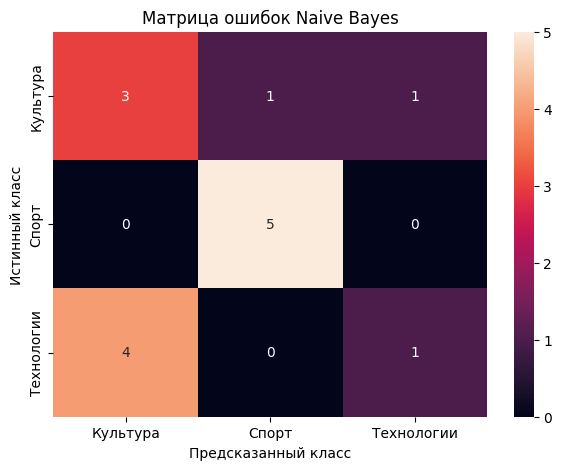

In [25]:
conf_mat_NB = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_mat_NB,
    annot=True,
    fmt='d',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок Naive Bayes')
plt.show()

### Оценка точности:

In [26]:
naive_acc = accuracy_score(y_test, y_pred)
print('Точность Naive Bayes:', round(naive_acc, 4))

Точность Naive Bayes: 0.6


## Задание 2. Обучите модель SVM (метод опорных векторов) для решения поставленной задачи, используя пайплайны и подбор оптимальных параметров

In [27]:
clf_svm = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('svc', SVC())
])

param_grid_svm = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'svc__C': [0.5, 1, 10],
    'svc__kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    clf_svm,
    param_grid_svm,
    cv=3,
    scoring='accuracy'
)

grid_svm.fit(X_train, y_train)

svm_model = grid_svm.best_estimator_
y_pred_SVM = svm_model.predict(X_test)

print('Лучшие параметры SVM:', grid_svm.best_params_)

Лучшие параметры SVM: {'svc__C': 0.5, 'svc__kernel': 'linear', 'vectorizer__ngram_range': (1, 1)}


### Вывод матрицы ошибок:

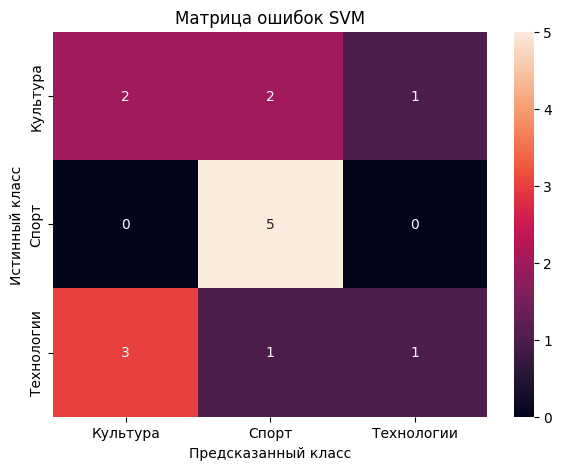

In [28]:
conf_mat_SVM = confusion_matrix(y_test, y_pred_SVM)

plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_mat_SVM,
    annot=True,
    fmt='d',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок SVM')
plt.show()

### Оценка точности:

In [29]:
svm_acc = accuracy_score(y_test, y_pred_SVM)
print('Точность SVM:', round(svm_acc, 4))

Точность SVM: 0.5333


## Задание 3. Обучите модель классификатора Decision Tree Classifier для решения поставленной задачи

In [30]:
clf_DecisionTree = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

clf_DecisionTree.fit(X_train, y_train)

y_pred_DT = clf_DecisionTree.predict(X_test)

### Вывод матрицы ошибок:

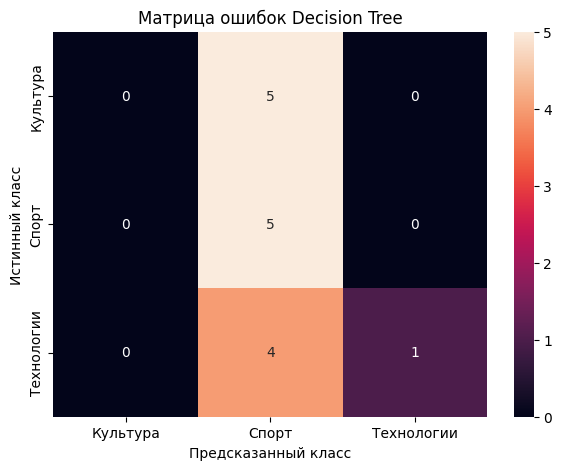

In [31]:
conf_mat_DT = confusion_matrix(y_test, y_pred_DT)

plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_mat_DT,
    annot=True,
    fmt='d',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок Decision Tree')
plt.show()

### Оценка точности:

In [32]:
dt_acc = accuracy_score(y_test, y_pred_DT)
print('Точность Decision Tree:', round(dt_acc, 4))

Точность Decision Tree: 0.4


## Задание 4. Обучите модель классификатора Random Forest Classifier для решения поставленной задачи

In [33]:
clf_rf = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

clf_rf.fit(X_train, y_train)

y_pred_RF = clf_rf.predict(X_test)

### Вывод матрицы ошибок:

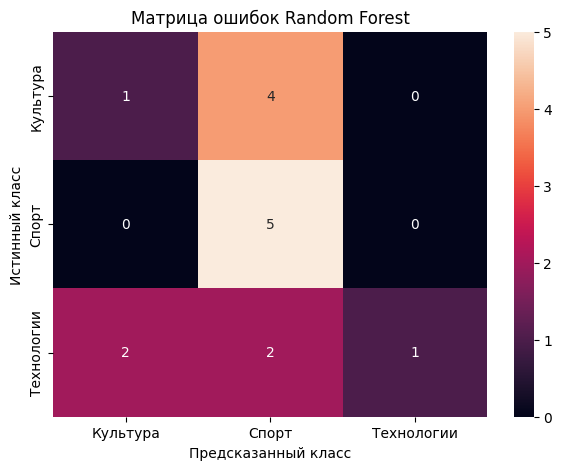

In [34]:
conf_mat_RF = confusion_matrix(y_test, y_pred_RF)

plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_mat_RF,
    annot=True,
    fmt='d',
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок Random Forest')
plt.show()

### Оценка точности:

In [35]:
rf_acc = accuracy_score(y_test, y_pred_RF)
print('Точность Random Forest:', round(rf_acc, 4))

Точность Random Forest: 0.4667


## Подведите общие итоги и сделайте выводы

,Модель,Точность
0,Naive Bayes,0.600000
1,SVM,0.533333
2,Decision Tree,0.400000
3,Random Forest,0.466667


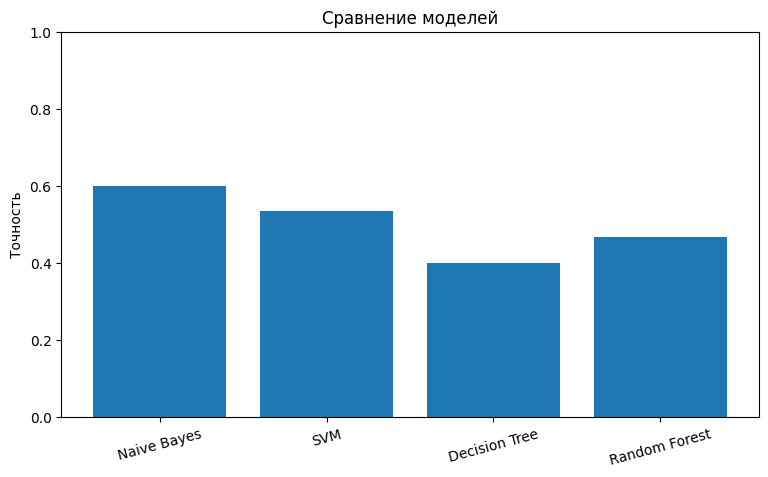

Сравнение методов векторизации:
Bag of Words: 0.6
TF-IDF: 0.6

Итог:
В работе были проверены методы Naive Bayes, SVM, Decision Tree и Random Forest
Для представления текста использовались Bag of Words и TF-IDF
Лучшие параметры Naive Bayes и SVM подбирались с помощью GridSearchCV


In [38]:
results = pd.DataFrame({
    'Модель': [
        'Naive Bayes',
        'SVM',
        'Decision Tree',
        'Random Forest'
    ],
    'Точность': [
        naive_acc,
        svm_acc,
        dt_acc,
        rf_acc
    ]
})

display(results)

plt.figure(figsize=(9, 5))
plt.bar(results['Модель'], results['Точность'])
plt.ylim(0, 1)
plt.ylabel('Точность')
plt.title('Сравнение моделей')
plt.xticks(rotation=15)
plt.show()

bow = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', MultinomialNB())
])

tfidf = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', MultinomialNB())
])

bow.fit(X_train, y_train)
tfidf.fit(X_train, y_train)

bow_pred = bow.predict(X_test)
tfidf_pred = tfidf.predict(X_test)

bow_acc = accuracy_score(y_test, bow_pred)
tfidf_acc = accuracy_score(y_test, tfidf_pred)

print('Сравнение методов векторизации:')
print('Bag of Words:', round(bow_acc, 4))
print('TF-IDF:', round(tfidf_acc, 4))

print()
print('Итог:')
print('В работе были проверены методы Naive Bayes, SVM, Decision Tree и Random Forest')
print('Для представления текста использовались Bag of Words и TF-IDF')
print('Лучшие параметры Naive Bayes и SVM подбирались с помощью GridSearchCV')

Ваши выводы записываются после запуска всех ячеек на основе полученных значений точности.